<a href="https://colab.research.google.com/github/amit20kr/Plant-Disease-Detection-/blob/main/PlantDisease_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# SETUP & DOWNLOAD

!pip install -q kaggle albumentations pandas

import os
import shutil
import random
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
import albumentations as A
import glob

# Secure Kaggle API Auth
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your kaggle.json file...")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

print("\n[OPERATION] Downloading PlantVillage Dataset via Kaggle API...")
!kaggle datasets download -d emmarex/plantdisease -q
!unzip -q plantdisease.zip -d temp_dataset/

print("[SUCCESS] Dataset downloaded and extracted to temporary storage.")

Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json

[OPERATION] Downloading PlantVillage Dataset via Kaggle API...
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
[SUCCESS] Dataset downloaded and extracted to temporary storage.


In [2]:
# RAW METADATA EXTRACTION
import os
import pandas as pd

# Local extracted directory
base_path = "temp_dataset/plantvillage dataset/color"
TARGET_SPECIES = ["Potato", "Tomato", "Pepper"]

print("[OPERATION] Scanning directory tree and building metadata DataFrame...\n")

if not os.path.exists(base_path):
    print(f"[ERROR] Path not found: {base_path}. Checking alternative structure...")
    # Fallback if structure differs slightly
    base_path = "temp_dataset/PlantVillage"

all_folders = os.listdir(base_path)
selected_classes = [f for f in all_folders if any(s in f for s in TARGET_SPECIES)]

data = []
for c in selected_classes:
    folder_path = os.path.join(base_path, c)
    if os.path.isdir(folder_path):
        images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg'))]
        species = c.split("___")[0] if "___" in c else c.split("_")[0]
        condition = "Healthy" if "healthy" in c.lower() else "Diseased"

        for img in images:
            data.append({
                "File_Name": img,
                "Class_Name": c,
                "Species": species,
                "Condition": condition,
                "File_Path": os.path.join(folder_path, img)
            })

df_raw = pd.DataFrame(data)

print(f"Total Images Found: {len(df_raw)}")
print("\nRaw File Structure (Class Distribution)")
if not df_raw.empty:
    class_counts = df_raw['Class_Name'].value_counts().reset_index()
    class_counts.columns = ['Class Name', 'Raw Image Count']
    display(class_counts)

[OPERATION] Scanning directory tree and building metadata DataFrame...

[ERROR] Path not found: temp_dataset/plantvillage dataset/color. Checking alternative structure...
Total Images Found: 20637

Raw File Structure (Class Distribution)


,Class Name,Raw Image Count
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1477
7,Tomato__Target_Spot,1404
8,Tomato_Early_blight,1000
9,Potato___Early_blight,1000


In [3]:
# DEEP IMAGE STATISTICS

from PIL import Image

print("[OPERATION] Extracting pixel dimensions and file sizes (This takes ~15 seconds)...\n")

widths, heights, sizes_kb = [], [], []

for path in df_raw['File_Path']:
    # Get File Size
    size = os.path.getsize(path) / 1024.0 # Convert to KB
    sizes_kb.append(size)

    # Get Dimensions without loading the full image into RAM
    with Image.open(path) as img:
        widths.append(img.size[0])
        heights.append(img.size[1])

df_raw['Width'] = widths
df_raw['Height'] = heights
df_raw['Size_KB'] = sizes_kb

print("Image Resolution & Size Summary")
# Statistical spread
summary_stats = df_raw[['Width', 'Height', 'Size_KB']].describe().round(2)
print(summary_stats)
print("\n[INSIGHT] If min/max dimensions vary wildly, it confirms the need for our resizing pipeline later.")

[OPERATION] Extracting pixel dimensions and file sizes (This takes ~15 seconds)...

Image Resolution & Size Summary
         Width   Height   Size_KB
count  20637.0  20637.0  20637.00
mean     256.0    256.0     16.19
std        0.0      0.0      4.45
min      256.0    256.0      3.36
25%      256.0    256.0     12.75
50%      256.0    256.0     16.60
75%      256.0    256.0     19.38
max      256.0    256.0     28.10

[INSIGHT] If min/max dimensions vary wildly, it confirms the need for our resizing pipeline later.


In [4]:
# STRICT MATHEMATICAL UNDERSAMPLING
import shutil
import os

MAX_IMAGES_PER_CLASS = 200
target_path = "hackathon_dataset/"
os.makedirs(target_path, exist_ok=True)

print(f"[OPERATION] Executing strict undersampling (Cap: {MAX_IMAGES_PER_CLASS} per class)...\n")

# If a class has < 200, it takes all of them (replace=False)
df_balanced = df_raw.groupby('Class_Name').apply(
    lambda x: x.sample(n=min(len(x), MAX_IMAGES_PER_CLASS), random_state=42)
, include_groups=False).reset_index()

print("[OPERATION] Migrating balanced images to final training directory...")

# Move the physical files based on our balanced DataFrame
moved_count = 0
for _, row in df_balanced.iterrows():
    src = row['File_Path']
    dst_folder = os.path.join(target_path, row['Class_Name'])
    dst = os.path.join(dst_folder, row['File_Name'])

    if os.path.exists(src):
        os.makedirs(dst_folder, exist_ok=True)
        shutil.move(src, dst)
        moved_count += 1
    elif os.path.exists(dst):
        # File already moved in a previous run
        moved_count += 1

# Only delete if we have migrated the files or if they are already gone
if os.path.exists("temp_dataset"):
    print("[CLEANUP] Removing temporary storage...")
    !rm -rf temp_dataset plantdisease.zip

print(f"[SUCCESS] {moved_count} images are ready in {target_path}.")

[OPERATION] Executing strict undersampling (Cap: 200 per class)...

[OPERATION] Migrating balanced images to final training directory...
[CLEANUP] Removing temporary storage...
[SUCCESS] 2952 images are ready in hackathon_dataset/.


In [5]:
# FINAL PREPROCESSING AUDIT

print("="*60)
print(" FINAL DATASET AUDIT REPORT (FOR JUDGING PANEL)")
print("="*60)

# 1. Total split by Condition (Healthy vs Diseased)
print("\nDistribution by Condition")
condition_summary = df_balanced.groupby('Condition').size().reset_index(name='Image Count')
condition_summary['Percentage'] = (condition_summary['Image Count'] / len(df_balanced) * 100).round(1).astype(str) + '%'
print(condition_summary.to_string(index=False))

# 2. Complex Pivot Table: Species vs Condition
print("\nMatrix: Species vs Condition ")
pivot = pd.crosstab(df_balanced['Species'], df_balanced['Condition'], margins=True, margins_name="Total")
print(pivot)

# 3. Final Class Counts
print("\nFinal Balanced Class Distribution")
final_counts = df_balanced['Class_Name'].value_counts().reset_index()
final_counts.columns = ['Class Name', 'Final Training Count']
print(final_counts.to_string(index=False))

print("="*60)
print(f"TOTAL READY FOR TENSORFLOW PIPELINE: {len(df_balanced)} IMAGES ")

 FINAL DATASET AUDIT REPORT (FOR JUDGING PANEL)

Distribution by Condition
Condition  Image Count Percentage
 Diseased         2400      81.3%
  Healthy          552      18.7%

Matrix: Species vs Condition 
Condition     Diseased  Healthy  Total
Species                               
Pepper__bell       200      200    400
Potato             400      152    552
Tomato            1800      200   2000
Total             2400      552   2952

Final Balanced Class Distribution
                                 Class Name  Final Training Count
              Pepper__bell___Bacterial_spot                   200
                     Pepper__bell___healthy                   200
                      Potato___Early_blight                   200
                       Potato___Late_blight                   200
                      Tomato_Bacterial_spot                   200
                        Tomato_Early_blight                   200
                         Tomato_Late_blight                  

In [6]:
# STRATIFIED SPLIT & LIST GENERATION

from sklearn.model_selection import train_test_split
import pandas as pd
import os

print("[OPERATION] Extracting arrays from balanced DataFrame...")

# Hardcoded Maps (To prevent underscore errors)
selected_classes = [
    "Pepper__bell___Bacterial_spot", "Pepper__bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Tomato_Bacterial_spot",
    "Tomato_Early_blight", "Tomato_Late_blight", "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot", "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot", "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus", "Tomato_healthy"
]

label_map = {k: i for i, k in enumerate(selected_classes)}

# Concepts: [is_healthy, has_spots, is_blighted, has_complex_pathogen]
concept_map = {
    "Pepper__bell___Bacterial_spot":               [0.0, 1.0, 0.0, 0.0],
    "Pepper__bell___healthy":                      [1.0, 0.0, 0.0, 0.0],
    "Potato___Early_blight":                       [0.0, 0.0, 1.0, 0.0],
    "Potato___Late_blight":                        [0.0, 0.0, 1.0, 0.0],
    "Potato___healthy":                            [1.0, 0.0, 0.0, 0.0],
    "Tomato_Bacterial_spot":                       [0.0, 1.0, 0.0, 0.0],
    "Tomato_Early_blight":                         [0.0, 0.0, 1.0, 0.0],
    "Tomato_Late_blight":                          [0.0, 0.0, 1.0, 0.0],
    "Tomato_Leaf_Mold":                            [0.0, 0.0, 0.0, 1.0],
    "Tomato_Septoria_leaf_spot":                   [0.0, 1.0, 0.0, 0.0],
    "Tomato_Spider_mites_Two_spotted_spider_mite": [0.0, 1.0, 0.0, 0.0],
    "Tomato__Target_Spot":                         [0.0, 1.0, 0.0, 0.0],
    "Tomato__Tomato_YellowLeaf__Curl_Virus":       [0.0, 0.0, 0.0, 1.0],
    "Tomato__Tomato_mosaic_virus":                 [0.0, 0.0, 0.0, 1.0],
    "Tomato_healthy":                              [1.0, 0.0, 0.0, 0.0]
}

# Build the lists directly from our audited df_balanced
image_paths = []
disease_labels = []
concept_labels = []

target_path = "hackathon_dataset/"

for _, row in df_balanced.iterrows():
    c_name = row['Class_Name']
    new_path = os.path.join(target_path, c_name, row['File_Name'])

    image_paths.append(new_path)
    disease_labels.append(label_map[c_name])
    concept_labels.append(concept_map[c_name])

print(f"[SUCCESS] Extracted {len(image_paths)} image paths.")
print("[OPERATION] Executing Stratified 70/15/15 Train/Val/Test Split...")

# Stratified Split (70% Train, 30% Temp)
X_train, X_temp, y_dis_train, y_dis_temp, y_conc_train, y_conc_temp = train_test_split(
    image_paths, disease_labels, concept_labels,
    test_size=0.30, stratify=disease_labels, random_state=42
)

# Second Split (Divide Temp exactly in half: 15% Val, 15% Test)
X_val, X_test, y_dis_val, y_dis_test, y_conc_val, y_conc_test = train_test_split(
    X_temp, y_dis_temp, y_conc_temp,
    test_size=0.50, stratify=y_dis_temp, random_state=42
)

# Stratification Audit
split_audit = pd.DataFrame({
    "Dataset Split": ["Training Set", "Validation Set (Clean)", "Test Set (Extreme Noise)"],
    "Image Count": [len(X_train), len(X_val), len(X_test)],
    "Percentage": [
        f"{len(X_train)/len(image_paths)*100:.1f}%",
        f"{len(X_val)/len(image_paths)*100:.1f}%",
        f"{len(X_test)/len(image_paths)*100:.1f}%"
    ],
    "Role": ["Weight Updates", "Convergence Monitoring", "Track A Robustness Proof"]
})

print("\n" + "="*65)
print(" STRATIFIED DATASET ARCHITECTURE (SLIDE ASSET)")
print("="*65)
print(split_audit.to_string(index=False))
print("="*65)

[OPERATION] Extracting arrays from balanced DataFrame...
[SUCCESS] Extracted 2952 image paths.
[OPERATION] Executing Stratified 70/15/15 Train/Val/Test Split...

 STRATIFIED DATASET ARCHITECTURE (SLIDE ASSET)
           Dataset Split  Image Count Percentage                     Role
            Training Set         2066      70.0%           Weight Updates
  Validation Set (Clean)          443      15.0%   Convergence Monitoring
Test Set (Extreme Noise)          443      15.0% Track A Robustness Proof


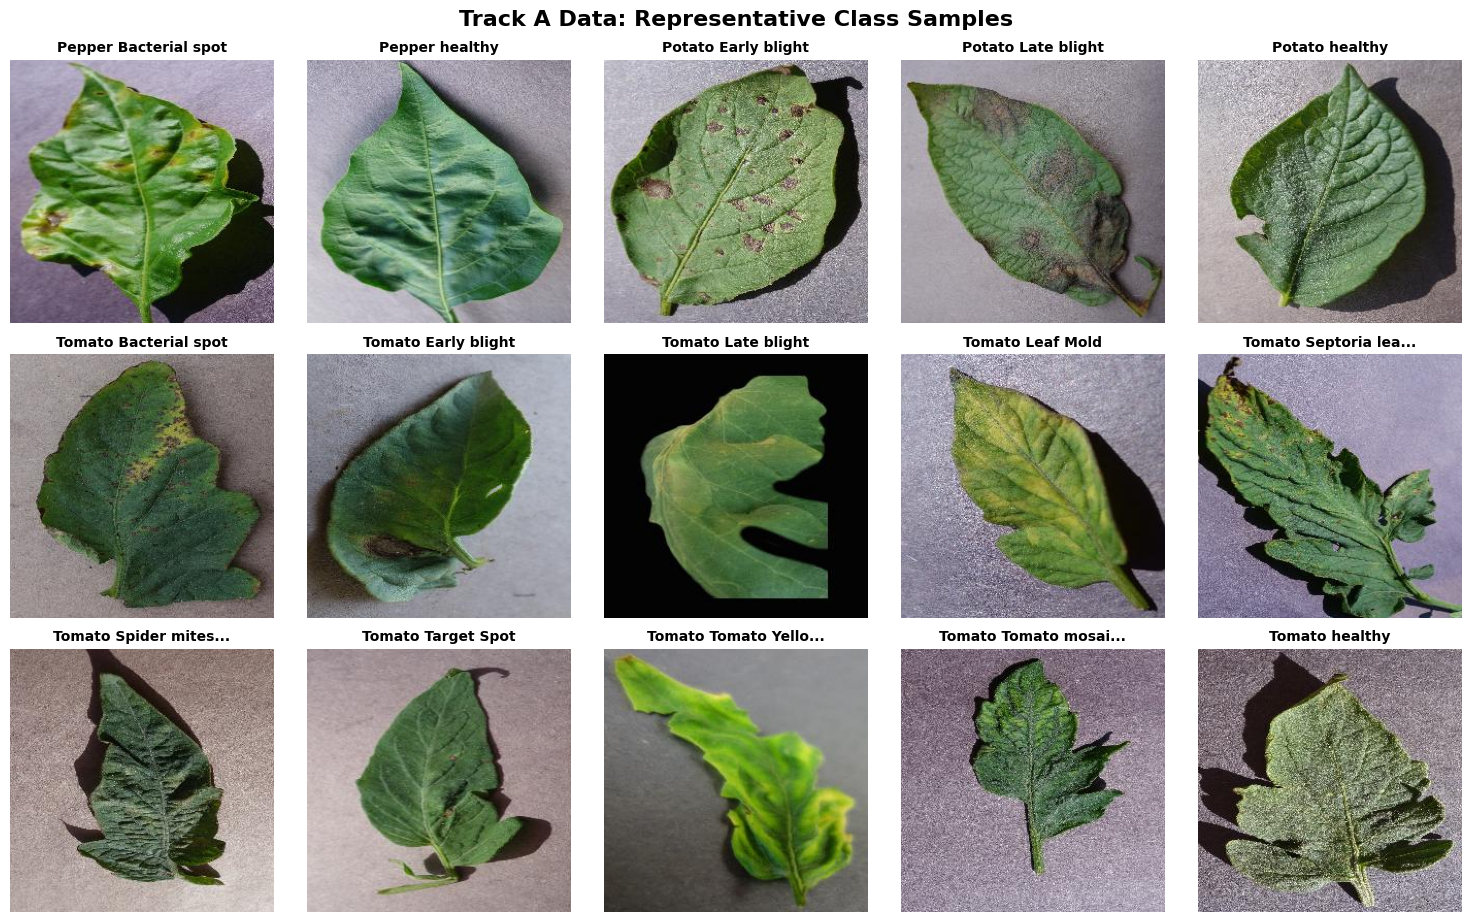

In [7]:
# DATASET VISUALIZATION
import matplotlib.pyplot as plt
import cv2
import random

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, c_name in enumerate(selected_classes):
    # Get all images belonging to this specific class
    class_imgs = [p for p, l in zip(image_paths, disease_labels) if label_map[c_name] == l]
    random_img_path = random.choice(class_imgs)

    # Read and convert color for matplotlib
    img = cv2.imread(random_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)

    # Clean up the long folder names for the slide title
    short_title = c_name.replace("Pepper__bell___", "Pepper ").replace("Tomato__", "Tomato ").replace("Potato___", "Potato ").replace("_", " ")
    if len(short_title) > 22:
        short_title = short_title[:19] + "..."

    axes[i].set_title(short_title, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Track A Data: Representative Class Samples", fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [8]:
# AGGRESSIVE AUGMENTATION PIPELINE
import albumentations as A
import cv2
import tensorflow as tf
import numpy as np

# Sabotage the training data so it cannot be memorized
transform_train = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.CoarseDropout(num_holes_range=(1, 5), hole_height_range=(10, 30), hole_width_range=(10, 30), p=0.5)
])

# Test set remains the extreme benchmark
transform_test = A.Compose([
    A.MotionBlur(blur_limit=7, p=1.0),
    A.GaussNoise(p=1.0),
    A.RandomBrightnessContrast(brightness_limit=-0.3, contrast_limit=0.3, p=1.0),
])

def process_wrapper(img_path, disease_idx, concept_array, split_type):
    img = cv2.imread(img_path.decode('utf-8'))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    split_type_str = split_type.decode('utf-8')
    if split_type_str == 'train':
        img = transform_train(image=img)['image']
    elif split_type_str == 'test':
        img = transform_test(image=img)['image']

    img = img.astype(np.float32)
    return img, concept_array, disease_idx

def get_tf_dataset(X, y_dis, y_conc, split_name, batch_size=32, shuffle=False):
    split_tensor = tf.constant([split_name] * len(X))

    def map_fn(path, dis, conc, split):
        img, c, d = tf.numpy_function(process_wrapper, [path, dis, conc, split], [tf.float32, tf.float32, tf.int32])

        img.set_shape([224, 224, 3])
        c.set_shape([4])
        d.set_shape([])

        return img, (c, d)

    ds = tf.data.Dataset.from_tensor_slices((X, y_dis, y_conc, split_tensor))
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("[OPERATION] Compiling hardened tf.data pipelines...")
train_ds = get_tf_dataset(X_train, y_dis_train, y_conc_train, 'train', shuffle=True)
val_ds   = get_tf_dataset(X_val, y_dis_val, y_conc_val, 'val')
test_ds  = get_tf_dataset(X_test, y_dis_test, y_conc_test, 'test')
print("[SUCCESS] Pipelines ready.")

[OPERATION] Compiling hardened tf.data pipelines...
[SUCCESS] Pipelines ready.


In [9]:
#HARDENED RESIDUAL CBM
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf

print("[OPERATION] Building Hardened Architecture...")

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    alpha=0.75
)
base_model.trainable = True

x = GlobalAveragePooling2D()(base_model.output)

# 40% Dropout to prevent memorization
x = Dropout(0.40)(x)

# L2 Regularization (0.01)
c_out = Dense(4, activation='sigmoid', name='C', kernel_regularizer=l2(0.01))(x)
combined_features = Concatenate()([x, c_out])
d_out = Dense(15, activation='softmax', name='D', kernel_regularizer=l2(0.01))(combined_features)

model = Model(inputs=base_model.input, outputs=[c_out, d_out])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=["binary_crossentropy", "sparse_categorical_crossentropy"],
    loss_weights=[0.4, 1.0],
    metrics=[["accuracy"], ["accuracy"]]
)

print("[SUCCESS] Hardened CBM compiled.")

[OPERATION] Building Hardened Architecture...
2910456/2910456 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[SUCCESS] Hardened CBM compiled.


In [10]:
# ARCHITECTURE & PARAMETER AUDIT
import pandas as pd
import tensorflow as tf

print("[OPERATION] Extracting Architecture Complexity Metrics")

# Extract Parameter Counts
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

audit_data = [
    {
        "Component/Metric": "Backbone Architecture",
        "Value": "MobileNetV3-Small (Alpha 0.75)",
        "Hackathon Impact": "Track C: Ultra-lightweight edge deployment"
    },
    {
        "Component/Metric": "Total Parameters",
        "Value": f"{total_params:,}",
        "Hackathon Impact": "Determines overall memory footprint on Android"
    },
    {
        "Component/Metric": "Trainable Parameters",
        "Value": f"{trainable_params:,}",
        "Hackathon Impact": "Unfrozen to adapt to real-world agricultural noise"
    },
    {
        "Component/Metric": "Non-trainable Parameters",
        "Value": f"{non_trainable_params:,}",
        "Hackathon Impact": "Frozen Batch-Normalization layers for stability"
    },
    {
        "Component/Metric": "Explainability Layer",
        "Value": "4-Node Sigmoid Bottleneck",
        "Hackathon Impact": "Track B: Forces semantic reasoning before prediction"
    }
]

df_model_audit = pd.DataFrame(audit_data)

print("\n" + "="*80)
print("ARCHITECTURE COMPLEXITY AUDIT (SLIDE ASSET)")
print("="*80)
print(df_model_audit.to_string(index=False))
print("="*80)

[OPERATION] Extracting Architecture Complexity Metrics

ARCHITECTURE COMPLEXITY AUDIT (SLIDE ASSET)
        Component/Metric                          Value                                     Hackathon Impact
   Backbone Architecture MobileNetV3-Small (Alpha 0.75)           Track C: Ultra-lightweight edge deployment
        Total Parameters                        591,447       Determines overall memory footprint on Android
    Trainable Parameters                        581,767   Unfrozen to adapt to real-world agricultural noise
Non-trainable Parameters                          9,680      Frozen Batch-Normalization layers for stability
    Explainability Layer      4-Node Sigmoid Bottleneck Track B: Forces semantic reasoning before prediction


In [11]:
# THE TRAINING ENGINE
print("[OPERATION] Training MVP Model...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)

[OPERATION] Training MVP Model...
Epoch 1/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - C_accuracy: 0.2836 - C_loss: 0.7398 - D_accuracy: 0.1191 - D_loss: 3.0994 - loss: 3.7621 - val_C_accuracy: 0.2641 - val_C_loss: 0.6187 - val_D_accuracy: 0.1512 - val_D_loss: 2.6626 - val_loss: 3.2678
Epoch 2/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - C_accuracy: 0.3272 - C_loss: 0.6081 - D_accuracy: 0.2836 - D_loss: 2.2409 - loss: 2.8424 - val_C_accuracy: 0.3318 - val_C_loss: 0.5646 - val_D_accuracy: 0.2190 - val_D_loss: 2.4332 - val_loss: 3.0134
Epoch 3/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - C_accuracy: 0.4022 - C_loss: 0.5491 - D_accuracy: 0.4831 - D_loss: 1.7102 - loss: 2.2861 - val_C_accuracy: 0.4402 - val_C_loss: 0.5360 - val_D_accuracy: 0.2822 - val_D_loss: 2.2292 - val_loss: 2.7951
Epoch 4/12
65/65 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - C_accuracy: 0.4850 - C_loss: 0.5045 - D_accuracy: 0.6157 - D_loss: 1.2720 - loss: 1.8267 - val_C_accuracy: 0.4650 - val_C_loss: 0.5203 - val_D_accuracy: 0.3

In [12]:
# Save the raw model
model.save("cbm_model.keras")
print("\n[SUCCESS] Master model trained and saved as cbm_model.keras")


[SUCCESS] Master model trained and saved as cbm_model.keras


In [14]:
# METRIC EXTRACTION & AUDIT
import pandas as pd

print("[OPERATION] Extracting training metrics for presentation...")

df_history = pd.DataFrame(history.history)

# Map the short Keras metric names to presentation-friendly names
df_history = df_history.rename(columns={
    'D_accuracy': 'Train Acc (Disease)',
    'val_D_accuracy': 'Val Acc (Disease)',
    'C_accuracy': 'Train Acc (Concepts)',
    'val_C_accuracy': 'Val Acc (Concepts)',
    'loss': 'Total Loss'
})

df_history.index.name = 'Epoch'
df_history.index += 1

deck_metrics = df_history[['Train Acc (Disease)', 'Val Acc (Disease)', 'Train Acc (Concepts)', 'Total Loss']].round(3)

print("\n" + "="*60)
print(" TRAINING CONVERGENCE REPORT")
print("="*60)
print(deck_metrics.to_string())
print("="*60)

[OPERATION] Extracting training metrics for presentation...

 TRAINING CONVERGENCE REPORT
       Train Acc (Disease)  Val Acc (Disease)  Train Acc (Concepts)  Total Loss
Epoch                                                                          
1                    0.119              0.151                 0.284       3.762
2                    0.284              0.219                 0.327       2.842
3                    0.483              0.282                 0.402       2.286
4                    0.616              0.321                 0.485       1.827
5                    0.702              0.375                 0.567       1.527
6                    0.775              0.427                 0.656       1.278
7                    0.802              0.494                 0.734       1.113
8                    0.817              0.562                 0.772       1.020
9                    0.862              0.555                 0.826       0.890
10                   0.879    

In [19]:
# FINAL METRICS SUMMARY
print("\n" + "="*50)
print(" FINAL MVP TRAINING RESULTS")
print("="*50)

final_train_acc = df_history['Train Acc (Disease)'].iloc[-1]
final_concept_acc = df_history['Train Acc (Concepts)'].iloc[-1]
final_loss = df_history['Total Loss'].iloc[-1]

print(f" Final Disease Accuracy (Train): {final_train_acc*100:.1f}%")
print(f" Final Concept Reasoning Acc:    {final_concept_acc*100:.1f}%")
print(f" Final Total Loss:               {final_loss:.3f}")
print("="*50)


 FINAL MVP TRAINING RESULTS
 Final Disease Accuracy (Train): 88.8%
 Final Concept Reasoning Acc:    89.4%
 Final Total Loss:               0.733


In [20]:
# INT8 QUANTIZATION FOR ANDROID

import os
import tensorflow as tf
import pandas as pd

print("[OPERATION] Initiating INT8 Post-Training Quantization...")

# Feed the converter real images so it knows how to scale the 8-bit integers
def representative_data_gen():
    # Take 100 images from the training dataset
    for input_value, _ in train_ds.unbatch().take(100):
        yield [tf.expand_dims(input_value, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

# compression
tflite_model = converter.convert()

with open('edge_model.tflite', 'wb') as f:
    f.write(tflite_model)

original_size = os.path.getsize("cbm_model.keras") / (1024 * 1024)
quantized_size = os.path.getsize("edge_model.tflite") / (1024 * 1024)

df_size = pd.DataFrame([{
    "Format": "FP32 (.keras)", "Size (MB)": round(original_size, 2), "Target": "Cloud"
}, {
    "Format": "INT8 (.tflite)", "Size (MB)": round(quantized_size, 2), "Target": "Android Offline"
}])

print("\n" + "="*60)
print(" TRACK C VERIFIED: LIGHTWEIGHT AI AUDIT")
print("="*60)
print(df_size.to_string(index=False))
print("="*60)
print(f" Compression Ratio: {original_size/quantized_size:.1f}x smaller")

[OPERATION] Initiating INT8 Post-Training Quantization...
Saved artifact at '/tmp/tmpgn3zvu7o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  List[TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)]
Captures:
  133928617225744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617227088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617226704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617225552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617226320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617224208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617227472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617226128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133928617224784: TensorSpec(sha

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



 TRACK C VERIFIED: LIGHTWEIGHT AI AUDIT
        Format  Size (MB)          Target
 FP32 (.keras)       7.34           Cloud
INT8 (.tflite)       0.78 Android Offline
 Compression Ratio: 9.4x smaller


In [22]:
# SECURE ARTIFACTS TO LOCAL MACHINE
from google.colab import files

print("[OPERATION] Downloading Master Models to local computer")
# Download the raw weights for Notebook 2
files.download("cbm_model.keras")

# Download the Android App model
files.download("edge_model.tflite")
print("[SUCCESS] Downloaded to local computer successfully")

[OPERATION] Downloading Master Models to local computer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[SUCCESS] Downloaded to local computer successfully
